In [34]:
import tensorflow as tf
from tensorflow import keras 
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [35]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [36]:
X_train.shape

(60000, 28, 28)

In [37]:
X_train = X_train / 255
X_test = X_test / 255

In [38]:
X_train_flattened = X_train.reshape(len(X_train),28*28)
X_test_flattened = X_test.reshape(len(X_test), 28 * 28)
X_train_flattened.shape

(60000, 784)

In [39]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics =['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

c:\Users\boogey\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


In [ ]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9245 - loss: 0.2686


[0.2685793340206146, 0.9244999885559082]

In [ ]:
prediction = model.predict(X_test_flattened[0:1])
predicted_digit = np.argmax(prediction[0])

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted digit: 7
Actual digit: 7


In [ ]:
prediction = model.predict(X_test_flattened)
prediction_labels = [np.argmax(i) for i in prediction]
prediction_labels[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [ ]:
cm =  tf.math.confusion_matrix(labels=y_test, predictions= prediction_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 963,    0,    1,    1,    0,    5,    4,    4,    1,    1],
       [   0, 1108,    3,    2,    0,    1,    4,    2,   15,    0],
       [   8,    9,  915,   21,    8,    3,   13,   14,   37,    4],
       [   2,    0,   12,  938,    0,   20,    2,   14,   17,    5],
       [   2,    1,    4,    1,  909,    0,   10,    8,   10,   37],
       [   9,    1,    2,   48,    9,  766,   13,    9,   28,    7],
       [  13,    3,    6,    1,    7,   12,  911,    2,    3,    0],
       [   1,    5,   22,    6,    4,    1,    0,  965,    2,   22],
       [   8,    8,    5,   34,    9,   23,    9,   14,  859,    5],
       [  11,    5,    1,   13,   23,    5,    0,   34,    6,  911]],
      dtype=int32)>

Text(95.83333333333333, 0.5, 'Truth')

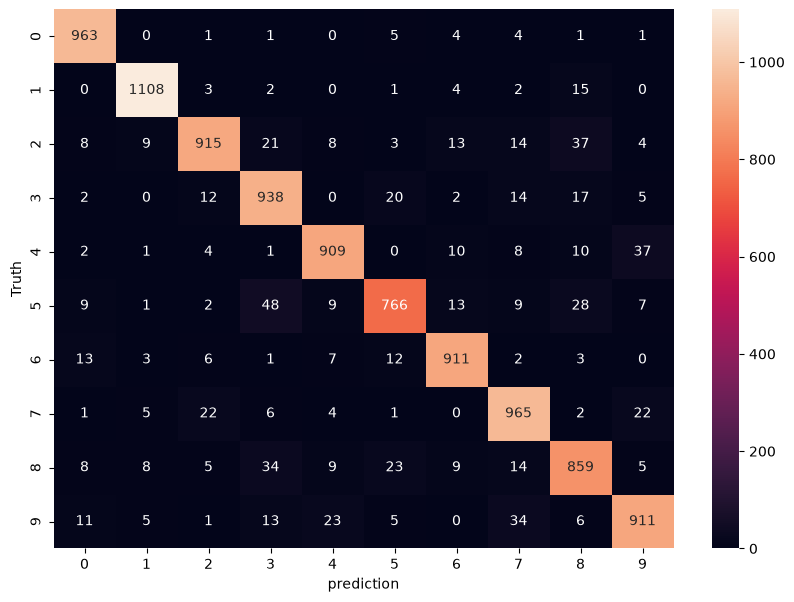

In [ ]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('prediction')
plt.ylabel('Truth')

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation = 'relu'),
    keras.layers.Dense(10, activation = 'sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

c:\Users\boogey\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9231 - loss: 0.2703
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9632 - loss: 0.1247
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9736 - loss: 0.0873
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9789 - loss: 0.0670
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9834 - loss: 0.0521


Text(95.83333333333333, 0.5, 'Truth')

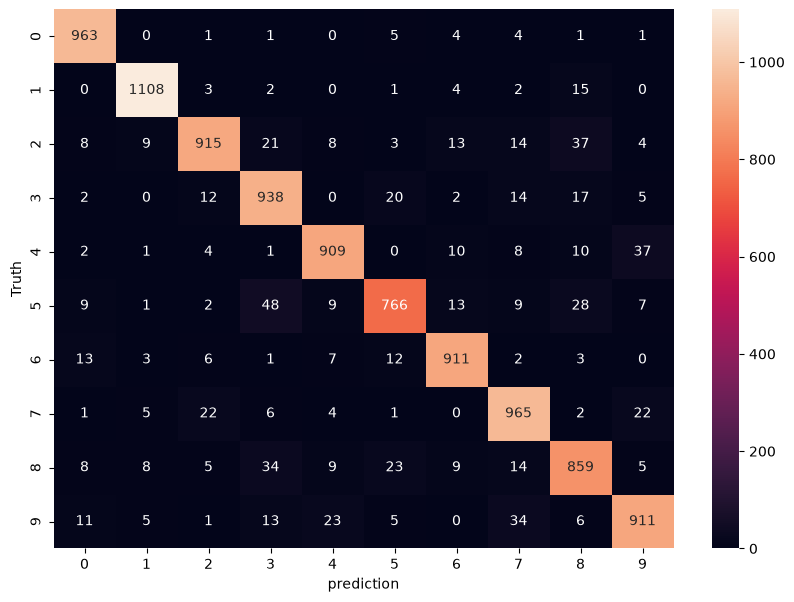

In [ ]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('prediction')
plt.ylabel('Truth')